![Kenya Food Price Early Warning System](images/banner.png)

# Kenya Food Price Early Warning System


Forecasting staple food prices across Kenyan markets to give farmers, traders, and food security actors the early signal they currently lack.

## 1. Business Understanding

## 1.1 Background

Food prices in Kenya are highly seasonal and can change sharply across markets. Staples such as maize and beans are affected by harvest cycles, rainfall, supply conditions, and limited access to timely market information.

For farmers, this creates a difficult decision: sell early and risk missing a better price, or wait and risk a price drop. Traders and institutions face a similar problem when deciding when to buy, store, release, or distribute food.

The problem is not a lack of historical data. Kenya has publicly available market price data, but this information is mainly used to understand what has already happened.

This project aims to turn that historical information, together with weather data, into a forward-looking system that shows **where prices are likely to move and when unusual price changes may be starting.**

## 1.2 Problem Statement

Farmers, traders, and food security institutions often make decisions using current or historical prices rather than reliable forecasts of what may happen next.

This can lead to poor selling and buying decisions, increased inventory risk, and delayed responses to food price shocks. Institutions may only act once a shortage or price increase is already visible.

The core problem is therefore not the absence of data. It is the lack of a system that combines historical prices and external factors such as weather to produce **market-specific forecasts and early warnings.**

## 1.3 Business Objectives

The project aims to:

1. **Provide forward-looking price visibility**  
   Forecast commodity prices 2–3 months ahead for individual markets.

2. **Detect emerging price shocks**  
   Identify when actual prices begin to move significantly away from expected prices.

3. **Improve access to market intelligence**  
   Present forecasts and trends through a simple interactive dashboard that non-technical users can understand.

4. **Support institutional decisions**  
   Provide quantitative signals that can support decisions around food reserves, subsidies, procurement, and humanitarian response.

5. **Build a reproducible system**  
   Create an automated pipeline from data collection and processing to forecasting and dashboard deployment.

### 1.4 Stakeholder Analysis

The system is designed for people who make decisions around food prices, from farmers and traders to government and humanitarian organizations.

**Smallholder Farmers and Cooperatives**
Need to decide when to sell, how much to sell, and whether holding stock could lead to a better return. Price forecasts can give them greater visibility into upcoming market conditions.

**Traders and Market Intermediaries**
Need to decide when and where to buy, store, and sell commodities. Forecasts can help them manage inventory and reduce the risk of buying at a peak or holding through a price decline.

**County Agricultural Offices and NDMA**
Need early signals of localized food price stress. Market-level forecasts and anomaly alerts can help them identify emerging risks before they become wider food security problems.

**NGOs and Humanitarian Organizations**
Need to plan procurement and cash-based interventions efficiently. Earlier visibility into price movements can help them act before rising prices reduce the purchasing power of their interventions.

**National Cereals and Produce Board**
Needs to make better decisions around strategic reserves, procurement, and price stabilization. Forecasts can provide an additional signal when deciding when to buy or release stock.

**Urban Consumers and Low-Income Households**
Are highly sensitive to changes in staple food prices. Earlier information about expected price movements can help households and organizations supporting them prepare for potential increases.

**Food Processors and Millers**
Need predictable input costs to manage production and pricing. Forward-looking commodity prices can support better procurement and planning.

Across these groups, the common need is **timely, market-specific information about where food prices are heading**. The forecasting and anomaly detection components are designed to provide that signal.


## 1.5 Business Success Criteria

The project will be considered successful if:

- Forecasts perform better than a simple baseline such as the last observed price or seasonal average.
- The anomaly detection system identifies meaningful price shocks without producing excessive false alarms.
- A non-technical user can select a market and commodity and quickly understand the expected price, forecast range, and alert status.
- The entire data pipeline is reproducible and can be refreshed without significant manual work.
- The system uses reliable and accessible public data sources so it can be extended beyond the capstone.

## 1.6 Data Mining Goals

The data science work will focus on five main tasks:

1. Build a **Prophet forecasting model** as the baseline.
2. Build an **LSTM model** for comparison.
3. Combine WFP Kenya food price data with NASA POWER weather data using market location and date.
4. Build a **residual-based anomaly detection system** to identify unusual price movements.
5. Compare the models using **MAE and MAPE** across commodities and markets.

The final forecasts and alerts will be presented through an interactive **Streamlit dashboard**.

## 1.7 Data Mining Success Criteria

The technical implementation will be considered successful if:

- The forecasting models outperform the chosen naive baseline across most market-commodity combinations.
- Forecast accuracy is evaluated using MAE and MAPE.
- The anomaly detector identifies historical price shocks while limiting false alerts.
- The price and weather datasets can be joined with minimal data loss.
- The pipeline can run end-to-end with minimal manual intervention.
- The deployed dashboard works reliably for the selected markets and commodities.

## 1.8 Hypotheses Guiding the Analysis

The analysis will test six hypotheses:

- **H1:** Maize prices follow a seasonal pattern around harvest periods.
- **H2:** Rainfall has a measurable lagged relationship with future commodity prices.
- **H3:** Price patterns differ significantly between markets.
- **H4:** Maize and bean prices show a relationship because they are commonly used as staple food substitutes.
- **H5:** Price volatility increases during drought periods.
- **H6:** Changes in wholesale prices are reflected in retail prices within one to two weeks.

These hypotheses will guide the exploratory analysis, feature engineering, modelling, and evaluation throughout the project.

## 2. Data Understanding

This section is highly  focused on understanding the data before cleaning, joining, and modelling.

The project uses two main data sources: the **WFP Kenya Food Prices dataset**, sourced through HDX, and daily weather data from the **NASA POWER API**.

The goal is to understand what each dataset contains, assess its quality, and look for early patterns that can help test the hypotheses from the Business Understanding phase.


### 2.1 Data Collection

The project uses two publicly accessible data sources.

**WFP Kenya Food Prices (HDX)**
Provides historical commodity prices by market, commodity, and date. This is the primary source for the target variable used in forecasting.

**NASA POWER API**
Provides daily weather observations, including rainfall and temperature. These variables are used as external features to test whether weather conditions can improve price forecasts.

The extraction date and source versions are recorded to ensure that the analysis can be reproduced using the same data snapshot.


In [34]:
# core libraries and notebook display settings
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests # used for routing and fetching our data and later in in demo(front end)
from datetime import datetime



In [35]:
# set display settings for the notebook

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 150)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

In [36]:
# record the date at which the last data was pulled.

extraction_date = datetime.now().strftime("%Y-%m-%d")

print(f"Data extraction date recorded: {extraction_date}")


Data extraction date recorded: 2026-09-01


In [37]:
# Load the Kenya food prices dataset. Add support for Kaggle and local loading seamlessly.

DATA_URL = (
    "https://data.humdata.org/dataset/"
    "e0d3fba6-f9a2-45d7-b949-140c455197ff/"
    "resource/517ee1bf-2437-4f8c-aa1b-cb9925b9d437/"
    "download/wfp_food_prices_ken.csv"
)

# define a filename
FILENAME = "wfp_food_prices_ken.csv"


def load_food_prices():
    """
    Load the Kenya food prices dataset.

    The function automatically checks for a Kaggle copy,
    a previously saved local copy, or the original source URL.

    It returns:
        pandas.DataFrame
            Raw Kenya food prices dataset.
    """

    # check if the notebook is running on Kaggle
    kaggle_root = "/kaggle/input"

    if os.path.exists(kaggle_root):

        # search for the dataset inside the Kaggle input directory
        for root, _, files in os.walk(kaggle_root):

            if FILENAME in files:

                kaggle_path = os.path.join(root, FILENAME)

                try:
                    prices_raw = pd.read_csv(kaggle_path)

                    print(f"Loaded dataset from Kaggle: {kaggle_path}")

                    return prices_raw

                except Exception as error:
                    print(f"Kaggle file could not be read: {error}")

    # check if a previously downloaded local copy exists
    if os.path.exists(FILENAME):

        try:
            prices_raw = pd.read_csv(FILENAME)

            print(f"Loaded local dataset: {FILENAME}")

            return prices_raw

        except Exception as error:
            print(f"Local file could not be read: {error}")

    # try downloading from the source URL
    print("Dataset not found locally. Trying the source URL...")

    try:
        response = requests.get(
            DATA_URL,
            timeout=30
        )

        response.raise_for_status()

        # save the downloaded file locally for future use
        with open(FILENAME, "wb") as file:
            file.write(response.content)

        prices_raw = pd.read_csv(FILENAME)

        print(f"Dataset downloaded and saved as '{FILENAME}'")

        return prices_raw

    except Exception as error:
        print(f"Download failed: {error}")

    # final fallback to the local file
    if os.path.exists(FILENAME):

        print("Using the previously saved local dataset.")

        return pd.read_csv(FILENAME)

    raise FileNotFoundError(
        "Could not load the Kenya food prices dataset. "
        "Check your internet connection or provide a local copy."
    )


In [38]:
# Load the dataset
prices_raw = load_food_prices()

# Output the first 5 rows
prices_raw.head()

Loaded local dataset: wfp_food_prices_ken.csv


,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,cereals and tubers,Maize (white),67,90 KG,actual,Wholesale,KES,1480.00,20.58
1,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans,50,KG,actual,Wholesale,KES,33.63,0.47
2,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans (dry),262,90 KG,actual,Wholesale,KES,3246.00,45.15
3,2006-01-15,Eastern,Kitui,Kitui,187,-1.37,38.02,cereals and tubers,Maize (white),67,KG,actual,Retail,KES,17.00,0.24
4,2006-01-15,Eastern,Kitui,Kitui,187,-1.37,38.02,cereals and tubers,Potatoes (Irish),148,50 KG,actual,Wholesale,KES,1249.99,17.39


In [39]:
# drop the units/description row if present, then fix dtypes 

def clean_price_data(prices_raw):
    """Clean and convert data types in the raw price dataset."""

    # Remove the units/description row if present
    if prices_raw.iloc[0].astype(str).str.startswith("#").any():

        prices = prices_raw.iloc[1:].reset_index(drop=True)

    else:

        prices = prices_raw.copy()

    # Convert date and price columns to the correct data types
    prices["date"] = pd.to_datetime(
        prices["date"],
        errors="coerce"
    )

    prices["price"] = pd.to_numeric(
        prices["price"],
        errors="coerce"
    )

    # Convert USD price if the column exists
    if "usdprice" in prices.columns:

        prices["usdprice"] = pd.to_numeric(
            prices["usdprice"],
            errors="coerce"
        )

    return prices


In [40]:
prices = clean_price_data(prices_raw)

In [41]:
print(f"Rows: {prices.shape[0]}, Columns: {prices.shape[1]}")
print(f"Date range: {prices['date'].min()} to {prices['date'].max()}")

Rows: 27763, Columns: 16
Date range: 2006-01-15 00:00:00 to 2026-08-15 00:00:00


In [42]:
# Get a sample of daily weather data from the NASA POWER API.
def get_weather_sample(
    latitude,
    longitude,
    start="20240101",
    end="20240131"
):
    """

    It returns:
        dict
            Weather parameters returned by the API.
    """

    power_url = "https://power.larc.nasa.gov/api/temporal/daily/point"

    params = {
        "parameters": "T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M",
        "community": "ag",
        "longitude": longitude,
        "latitude": latitude,
        "start": start,
        "end": end,
        "format": "JSON",
    }

    # ping the url and pass a timeout to avoid out of control requests
    response = requests.get(
        power_url,
        params=params,
        timeout=30
    )

    # raise an error if the API request failed
    response.raise_for_status()
    print(f" status code {response.status_code}")


    power_sample = response.json()

    return power_sample["properties"]["parameter"]




In [43]:
# sample call for Nairobi to confirm the API and response structure
nairobi_lat, nairobi_lon = -1.2864, 36.8172

sample_params = get_weather_sample(
    latitude=nairobi_lat,
    longitude=nairobi_lon
)


 status code 200


In [44]:

print("Parameters returned:", list(sample_params.keys()))
print("Sample PRECTOTCORR values:", list(sample_params["PRECTOTCORR"].items())[:5])

Parameters returned: ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M']
Sample PRECTOTCORR values: [('20240101', 0.31), ('20240102', 1.38), ('20240103', 0.28), ('20240104', 1.51), ('20240105', 1.56)]


### NASA POWER Weather Variables

The NASA POWER API provides several weather variables that can be used to understand conditions that may influence commodity prices.

| Parameter | Description | Unit |
|---|---|---|
| `T2M` | Average air temperature measured 2 meters above the surface | °C |
| `T2M_MAX` | Maximum air temperature measured at 2 meters | °C |
| `T2M_MIN` | Minimum air temperature measured at 2 meters | °C |
| `T2M_RANGE` | Difference between the daily maximum and minimum temperature | °C |
| `RH2M` | Relative humidity measured at 2 meters | % |
| `WS2M` | Average wind speed measured at 2 meters | m/s |
| `PS` | Atmospheric pressure at the surface | kPa |
| `PRECTOTCORR` | Bias-corrected total precipitation | mm/day |
| `ALLSKY_SFC_SW_DWN` | Total solar radiation reaching the surface under all sky conditions | kW-hr/m²/day |

For this project, **rainfall and temperature** are the primary weather variables of interest because they have the strongest potential relationship with agricultural production and future commodity prices.

### 2.2 Data Description

Before combining the datasets, we first need to understand how each one is structured.

The **price dataset** contains one observation for a specific commodity, market, and date.

The **weather dataset** contains daily weather observations for a specific geographic location.

This structure allows the two datasets to be joined using **market location and date**.


In [45]:
# column level summary: dtype, uniqueness, missingness
data_dictionary = pd.DataFrame({
    "column": prices.columns,

    "dtype": [str(prices[col].dtype) for col in prices.columns],

    "n_unique": [prices[col].nunique() for col in prices.columns],

    "n_missing": [prices[col].isna().sum() for col in prices.columns],

    "pct_missing": [(prices[col].isna().mean() * 100).round(2) for col in prices.columns],
})

data_dictionary

,column,dtype,n_unique,n_missing,pct_missing
0,date,datetime64[us],248,0,0.00
1,admin1,str,7,62,0.22
2,admin2,str,27,62,0.22
3,market,str,226,0,0.00
4,market_id,int64,226,0,0.00
5,latitude,float64,182,62,0.22
6,longitude,float64,184,62,0.22
7,category,str,8,0,0.00
8,commodity,str,51,0,0.00
9,commodity_id,int64,51,0,0.00


In [46]:
# scale and spread of the two numeric price fields

prices[["price", "usdprice"]].describe()

,price,usdprice
count,27763.000000,27763.000000
mean,1308.392522,11.949639
std,2583.636443,22.958342
min,5.000000,0.039000
25%,70.000000,0.610000
50%,130.000000,1.030000
75%,993.000000,9.045000
max,19800.000000,184.820000


In [47]:
# check for duplicate rows at the expected grain

grain_columns = ["date", "market", "commodity", "pricetype"]

duplicate_count = prices.duplicated(subset=grain_columns).sum()

In [48]:
print(f"Duplicate rows at (date, market, commodity, pricetype) grain: {duplicate_count}")
print(f"Unique markets: {prices['market'].nunique()}")
print(f"Unique commodities: {prices['commodity'].nunique()}")
print(f"Unique admin1 regions: {prices['admin1'].nunique()}")

Duplicate rows at (date, market, commodity, pricetype) grain: 0
Unique markets: 226
Unique commodities: 51
Unique admin1 regions: 7


### 2.3 Exploratory Data Analysis

Exploratory analysis is used to understand the main patterns in the price and weather data.

We first examine the individual variables to understand their distributions, ranges, and data coverage. We then look at relationships between variables, with a focus on how weather conditions relate to commodity prices.

Maize and beans are the main commodities of interest because they are central to the business objectives of the project.


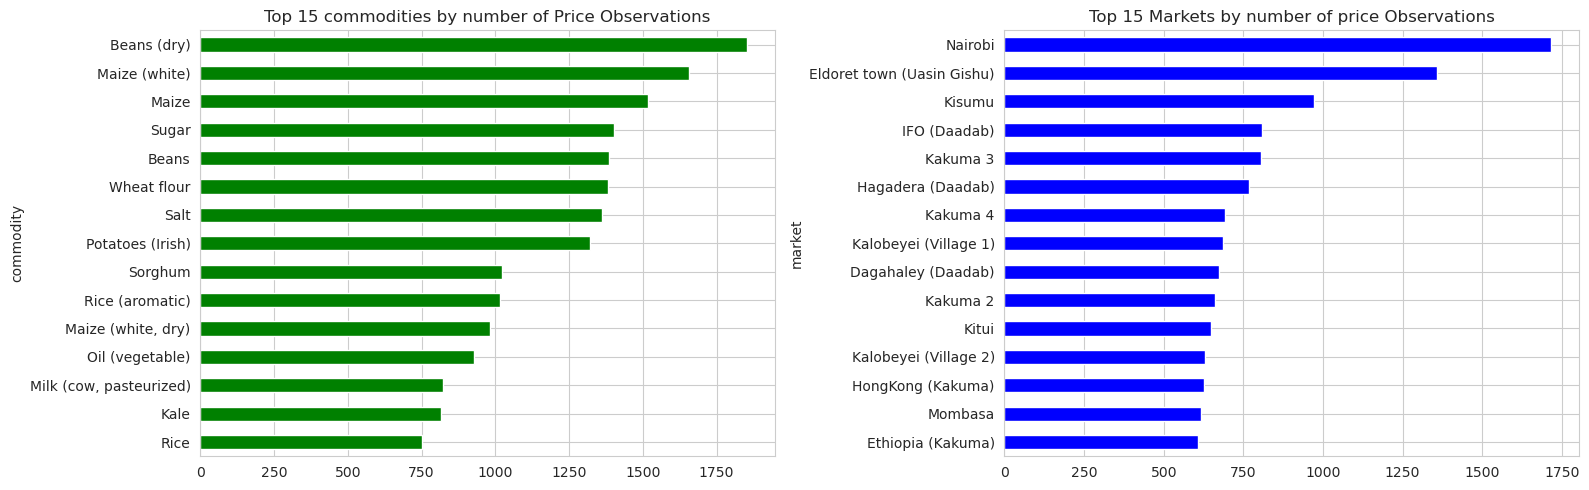

In [49]:
# top commodities and markets by number of price observation -- univariate analysis
commodity_counts = prices['commodity'].value_counts().head(15)
market_counts = prices["market"].value_counts().head(15)

#plot
fig, axes = plt.subplots(1,2, figsize=(16,5))
commodity_counts.plot(
    kind="barh", 
    ax=axes[0], 
    color='green')

axes[0].set_title("Top 15 commodities by number of Price Observations")
axes[0].invert_yaxis() #invert y-axis of first plot only

market_counts.plot(
    kind="barh", 
    ax=axes[1], 
    color='blue')

axes[1].set_title("Top 15 Markets by number of price Observations")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


Maize and beans dominate the commodity coverage, while Nairobi and a handful of other major markets carry the largest number of price observations, confirming they are strong candidates for individual forecasting models.

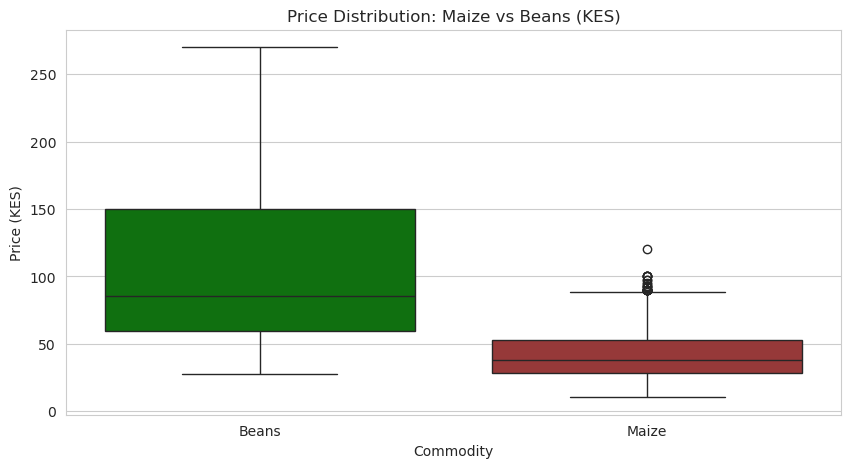

In [50]:
# price spread for the two priority commodities (Univariate)
priority_commodities = ["Maize", "Beans"]
subset = prices[prices["commodity"].isin(priority_commodities)]

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=subset, 
    x="commodity", 
    y="price", 
    palette=["green", "brown"],
    hue='commodity'
    )
plt.title("Price Distribution: Maize vs Beans (KES)")
plt.ylabel("Price (KES)")
plt.xlabel("Commodity")
plt.show()

Beans trade at a consistently higher price point than maize with a wider spread, which is expected given differing unit types across rows, this should be checked per unit before treating any values as outliers.

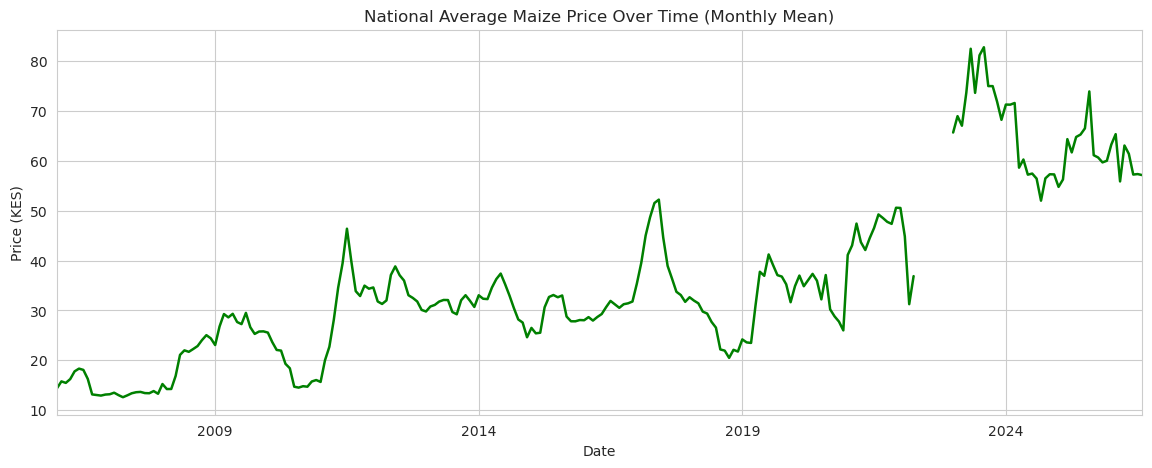

In [51]:
# national average maize price by month (univariate)
maize = prices[prices["commodity"] == "Maize"].copy()
maize_monthly = maize.groupby(
    pd.Grouper(
        key="date", 
        freq="ME")
        )["price"].mean()

plt.figure(figsize=(14, 5))
maize_monthly.plot(color="green", linewidth=1.8)
plt.title("National Average Maize Price Over Time (Monthly Mean)")
plt.ylabel("Price (KES)")
plt.xlabel("Date")
plt.show()

Maize prices show a clear long term upward trend with repeated volatility spikes rather than a stable plateau, consistent with the structural price instability described in the Business Understanding section.

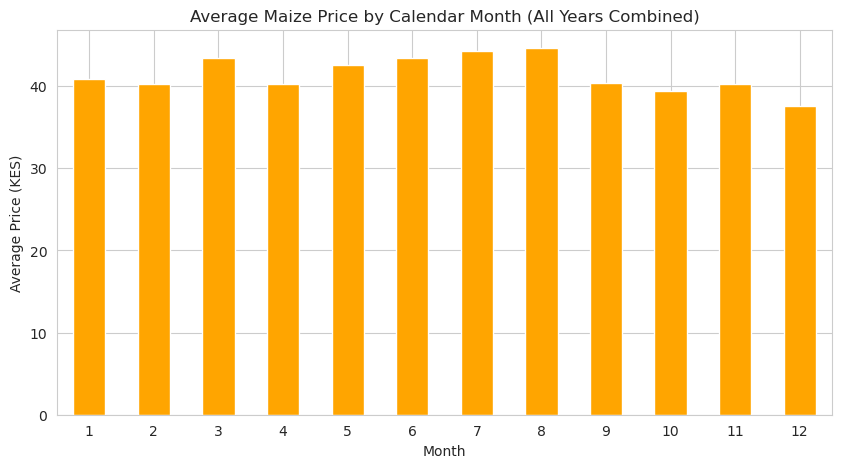

In [52]:
# average maize price by calendar month, all years combined (univariate)
maize["month"] = maize["date"].dt.month
seasonal_avg = maize.groupby("month")["price"].mean()

plt.figure(figsize=(10, 5))
seasonal_avg.plot(kind="bar", color="orange")
plt.title("Average Maize Price by Calendar Month (All Years Combined)")
plt.xlabel("Month")
plt.ylabel("Average Price (KES)")
plt.xticks(rotation=0)
plt.show()

Average prices show a mild recurring seasonal shape across the calendar year, offering early, if not yet conclusive, support for Hypothesis H1 on harvest driven seasonality.

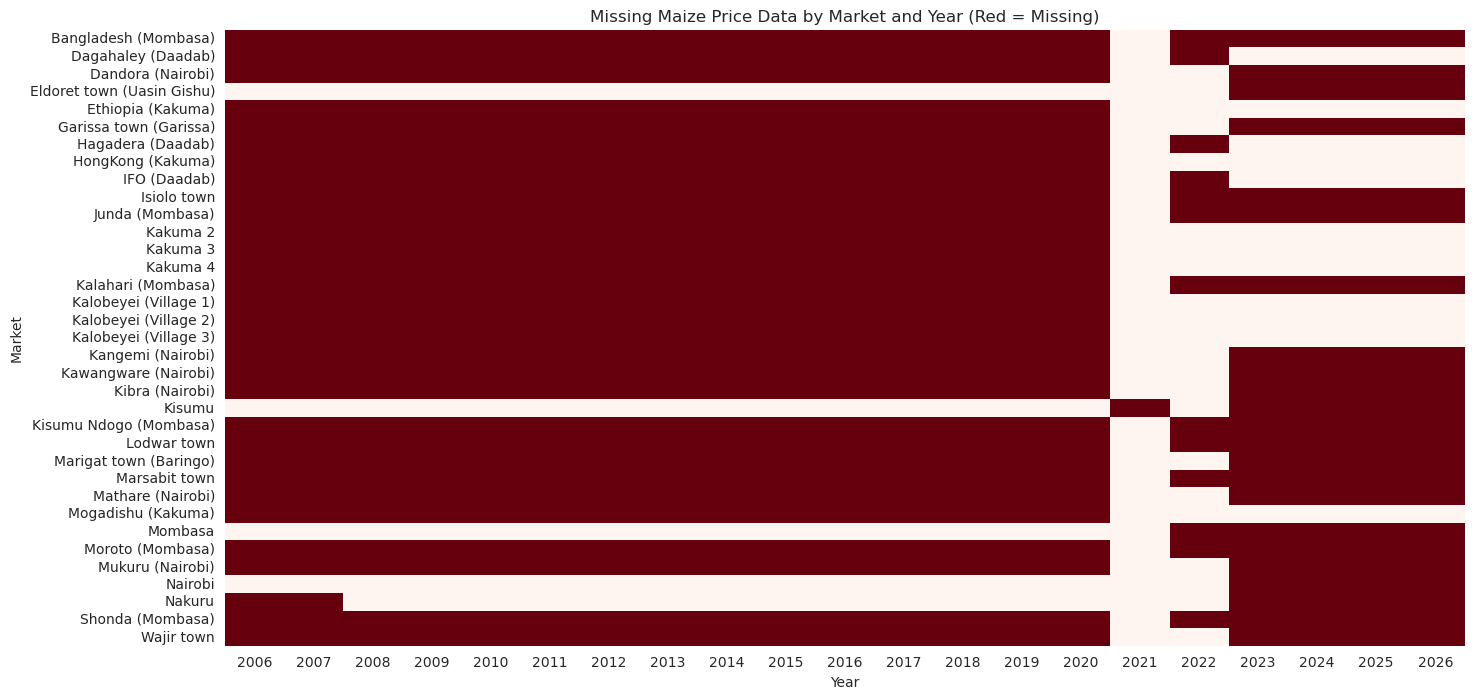

In [53]:
# missing maize price coverage by market and year (univariate)
pivot_check = maize.pivot_table(
    index="market",
    columns=maize["date"].dt.year,
    values="price",
    aggfunc="mean"
)

plt.figure(figsize=(16, 8))
sns.heatmap(pivot_check.isna(), cbar=False, cmap="Reds")
plt.title("Missing Maize Price Data by Market and Year (Red = Missing)")
plt.xlabel("Year")
plt.ylabel("Market")
plt.show()

Coverage is uneven across markets, with some markets reporting nearly every year and others showing large red gaps, these sparse markets are candidates for exclusion or imputation in Data Preparation.

In [54]:
# flag maize price outliers using the iqr method (univariate analysis)
q1 = maize["price"].quantile(0.25)
q3 = maize["price"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = maize[(maize["price"] < lower_bound) | (maize["price"] > upper_bound)]

In [55]:
print(f"IQR bounds: [{lower_bound:.2f}, {upper_bound:.2f}] KES")
print(f"Outlier observations detected: {len(outliers)} out of {len(maize)}")

IQR bounds: [-7.88, 88.73] KES
Outlier observations detected: 24 out of 1518


In [56]:
outliers[["date", "market", "price"]].sort_values("price", ascending=False).head(10)

,date,market,price
23557,2023-08-15,Dagahaley (Daadab),120.00
23171,2023-05-15,Ethiopia (Kakuma),100.00
24191,2024-01-15,Dagahaley (Daadab),100.00
23730,2023-09-15,HongKong (Kakuma),100.00
23719,2023-09-15,Ethiopia (Kakuma),100.00
24462,2024-03-15,HongKong (Kakuma),100.00
23485,2023-07-15,Kakuma 3,97.50
25025,2024-08-15,Dagahaley (Daadab),97.50
23206,2023-05-15,Kakuma 3,95.00
24415,2024-03-15,Dagahaley (Daadab),94.41


### 2.4 Weather Data Exploration

Rainfall and temperature are the two variables most directly tied to agricultural output, and by extension to price formation several months later. Kenya has a  known bimodal rainfall pattern, long rains from March to May and short rains from October to December,which provides a natural benchmark against which the retrieved data can be validated.

In [57]:
# daily rainfall and temperature for Nairobi, full year 2023 (univariate)
power_url = "https://power.larc.nasa.gov/api/temporal/daily/point"

params_full_year = {
    "parameters": "T2M,PRECTOTCORR",
    "community": "ag",
    "longitude": nairobi_lon,
    "latitude": nairobi_lat,
    "start": "20230101",
    "end": "20231231",
    "format": "JSON",
}

response_year = requests.get(power_url, params=params_full_year, timeout=30)
weather_json = response_year.json()["properties"]["parameter"]

weather_df = pd.DataFrame({
    "date": pd.to_datetime(list(weather_json["T2M"].keys()), format="%Y%m%d"),
    "temperature": list(weather_json["T2M"].values()),
    "rainfall": list(weather_json["PRECTOTCORR"].values()),
})

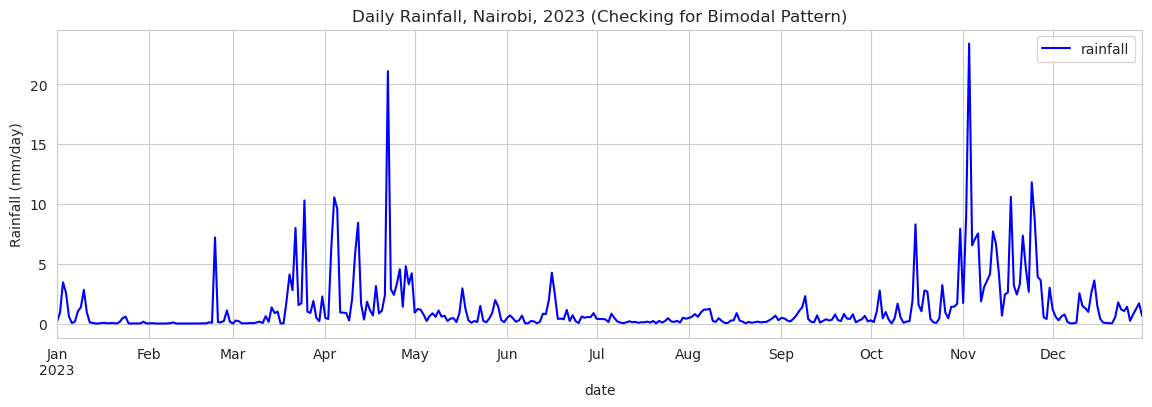

In [58]:
weather_df.set_index("date")[["rainfall"]].plot(figsize=(14, 4), color="blue")
plt.title("Daily Rainfall, Nairobi, 2023 (Checking for Bimodal Pattern)")
plt.ylabel("Rainfall (mm/day)")
plt.show()

Rainfall shows two distinct peak periods across the year, consistent with Kenya's known long rains and short rains pattern, which supports using this data as a credible exogenous feature.

### 2.5 Price and Weather Relationship

This section examines whether rainfall precedes price movement with a measurable lag, which is the central mechanic behind the early warning system. Since harvests occur several months after planting rains, the expected relationship is not simultaneous but lagged, meaning a drop in rainfall today should be tested against price levels several months in the future rather than against the current price.

In [59]:
# test rainfall to price correlation at 0 to 6 month lags
monthly_rainfall = weather_df.set_index("date")["rainfall"].resample("ME").sum()
monthly_price = maize_monthly

combined = pd.DataFrame({"rainfall": monthly_rainfall, "price": monthly_price}).dropna()

lag_results = {}
for lag in range(0, 7):
    shifted_rainfall = combined["rainfall"].shift(lag)
    lag_results[lag] = shifted_rainfall.corr(combined["price"])

lag_series = pd.Series(lag_results)

In [60]:
print("Correlation between rainfall (lagged) and maize price:")
print(lag_series.round(3))

Correlation between rainfall (lagged) and maize price:
0   -0.168
1   -0.101
2   -0.036
3    0.347
4    0.639
5    0.154
6   -0.183
dtype: float64


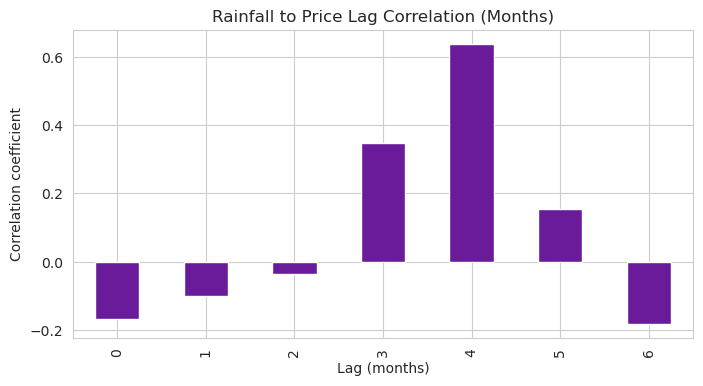

In [61]:
# rainfall to price lag correlation (Bivariate)
lag_series.plot(kind="bar", figsize=(8, 4), color="#6A1B9A")
plt.title("Rainfall to Price Lag Correlation (Months)")
plt.xlabel("Lag (months)")
plt.ylabel("Correlation coefficient")
plt.show()

This lag test currently uses only one calendar year of Nairobi weather against a multi year national price series, so the correlation values are indicative rather than conclusive, the proper version of this test happens once weather is pulled per market across the full date range in Data Preparation.

### 2.6 Coordinate Completeness

Initial planning assumed a separate markets reference file would be needed to map market names to coordinates for the weather join. Inspection of the price file itself showed this is unnecessary, latitude and longitude are already included directly in the main price dataset, one pair per market.

In [62]:
# confirm lat/lon exist directly in the price data
coordinate_columns = [col for col in prices.columns if "lat" in col.lower() or "lon" in col.lower()]
coord_check = prices.groupby("market")[coordinate_columns].nunique()

In [63]:
print("Coordinate related columns found:", coordinate_columns)
coord_check.head(10)

Coordinate related columns found: ['latitude', 'longitude']


,latitude,longitude
market,,
Adele Center,1,1
Alango Arba,1,1
Alemsekon,1,1
Alinjugur,1,1
Alungu,1,1
Amaya,1,1
Aposta,1,1
Archers Post,1,1
Ashabito,1,1


In [64]:
# identify which markets are missing coordinates
missing_coords = prices[prices["latitude"].isna()]["market"].unique()

In [65]:
print(f"Markets with missing coordinates: {len(missing_coords)}")
print(missing_coords)

Markets with missing coordinates: 1
<StringArray>
['Hola (Tana River)']
Length: 1, dtype: str


### 2.7 Data Quality Summary

The data is generally suitable for analysis, but a few issues need to be addressed before modelling.

* **Commodity names:** Maize appears under different labels. These will need to be reviewed and consolidated where appropriate.
* **Duplicates:** No duplicate observations were found at the market, commodity, date, and price type level.
* **Outliers:** A small number of maize price observations were flagged using the IQR method. These will be reviewed rather than removed automatically.
* **Market coordinates:** One market is missing latitude and longitude and will be excluded from the weather join.
* **Date coverage:** The price data spans from January 2006 to August 2026, providing a long historical period for analysis.

These findings will guide the data cleaning and preparation steps before modelling.


### 2.8 Initial Insights and Transition to Data Preparation

The data is generally clean and suitable for the next stage. We found no duplicate observations, and almost all markets have the coordinates needed to connect them with weather data.

The rainfall analysis also showed a relationship between rainfall and prices at a four-month lag, providing early support for **H2**. This is an initial finding and will be tested further using the full dataset.

The main issue to resolve is the way maize is labelled. Different maize variants appear as separate commodities and may have different price scales and units. This needs to be handled before outlier detection and modelling.

These findings guide the cleaning, transformation, and feature engineering steps in the **Data Preparation** phase.


## 3. Data Preparation

This phase prepares the data for analysis and modelling based on the findings from Data Understanding.

The data will be cleaned, transformed, and combined with weather data. Commodity labels will be preserved as reported in the source data rather than merging products that may have different price behaviour.

We will also check market and commodity coverage before making decisions about which data to use for modelling.


### 3.1 Commodity Landscape

Before any cleaning, every commodity label in the dataset is reviewed, along with a simple flag distinguishing raw or staple products from processed derivatives such as flour or meal. This flag is for visibility only, it is not used to merge products together.

In [66]:
commodity_overview = prices["commodity"].value_counts()
is_processed = prices["commodity"].str.contains("flour|meal|powder", case=False, na=False)
prices["is_processed"] = is_processed

In [67]:
print(f"Total distinct commodity labels: {prices['commodity'].nunique()}")
print(f"Processed or derivative product rows: {is_processed.sum()}")
print(commodity_overview.head(30))

Total distinct commodity labels: 51
Processed or derivative product rows: 2815
commodity
Beans (dry)                   1854
Maize (white)                 1656
Maize                         1518
Sugar                         1401
Beans                         1386
Wheat flour                   1380
Salt                          1362
Potatoes (Irish)              1320
Sorghum                       1021
Rice (aromatic)               1017
Maize (white, dry)             983
Oil (vegetable)                927
Milk (cow, pasteurized)        821
Kale                           817
Rice                           752
Oil (vegetable, fortified)     749
Maize flour                    745
Maize flour (white)            690
Milk (UHT)                     626
Bananas                        591
Tomatoes                       519
Cabbage                        485
Onions (dry)                   470
Meat (goat)                    402
Potatoes (Irish, white)        401
Beans (yellow)                 380
M

### 3.2 Unit Audit

Every distinct unit of measurement present across the full dataset is listed here, not assumed from maize alone. Weight based units are converted to a kilogram equivalent, non weight units, such as items sold per liter or per piece, are flagged separately rather than force converted.

In [68]:
unit_counts = prices["unit"].value_counts()

In [69]:
print(unit_counts)

unit
KG        14595
90 KG      4118
L          2715
50 KG      1905
200 G      1362
500 ML      804
Unit        591
64 KG       518
13 KG       470
126 KG      459
400 G       178
Head         26
Bunch        22
Name: count, dtype: int64


In [70]:
unit_to_kg = {
    "KG": 1,
    "90 KG": 90,
    "64 KG": 64,
    "50 KG": 50,
    "26 KG": 26,
    "126 KG": 126,
    "13 KG": 13,
    "200 G": 0.2,
    "400 G": 0.4,
}

prices["kg_equivalent"] = prices["unit"].map(unit_to_kg)
prices["price_per_kg"] = prices["price"] / prices["kg_equivalent"]

In [71]:
unmapped_units = prices[prices["kg_equivalent"].isna()]["unit"].unique()
print(f"Unmapped units, genuinely non weight based: {unmapped_units}")
print(f"Rows converted to price per kg: {prices['price_per_kg'].notna().sum()} out of {len(prices)}")

Unmapped units, genuinely non weight based: <StringArray>
['500 ML', 'L', 'Unit', 'Bunch', 'Head']
Length: 5, dtype: str
Rows converted to price per kg: 23605 out of 27763


### 3.3 Retail Price Selection

Retail prices are selected as the primary modeling series. This is a deliberate scoping decision, not an oversight, retail is the price point smallholder farmers, cooperatives, and urban consumers, the majority of beneficiary groups in the stakeholder analysis, actually transact on and can act upon directly. Wholesale price forecasting, most relevant to traders, NCPB, and millers, is a natural extension of this same pipeline, since wholesale rows remain intact in the source data and require no new data collection, only rerunning the completeness and modeling steps against `pricetype == "Wholesale"` instead. This is documented here as a defined next phase rather than an unaddressed gap.

In [72]:
retail = prices[prices["pricetype"] == "Retail"].copy()
print(f"Retail rows: {len(retail)} out of {len(prices)} total rows")

Retail rows: 18608 out of 27763 total rows


In [73]:
wholesale_rows = prices[prices["pricetype"] == "Wholesale"]
print(f"Wholesale rows available: {len(wholesale_rows)}")
print(f"Retail rows available: {len(retail)}")

Wholesale rows available: 9155
Retail rows available: 18608


### 3.4 Market and Commodity Completeness 

Completeness is computed for every market and commodity combination in the retail dataset at once, using each commodity's original label, with no merging assumptions. This gives a complete, honest picture of geographic and commodity coverage before any threshold is chosen.

In [74]:
coverage = (
    retail
    .groupby(["market", "commodity"])["date"]
    .nunique()
    .reset_index(name="months_reported")
)

total_months_available = retail["date"].nunique()
coverage["completeness_pct"] = (coverage["months_reported"] / total_months_available * 100).round(1)

In [75]:
print(f"Total market-commodity pairs: {len(coverage)}")
for threshold in [30, 40, 50, 60, 70]:
    qualifying = coverage[coverage["completeness_pct"] >= threshold]
    print(f"At {threshold} percent threshold: {len(qualifying)} pairs, {qualifying['market'].nunique()} markets, {qualifying['commodity'].nunique()} commodities")

Total market-commodity pairs: 2546
At 30 percent threshold: 8 pairs, 5 markets, 5 commodities
At 40 percent threshold: 8 pairs, 5 markets, 5 commodities
At 50 percent threshold: 7 pairs, 4 markets, 5 commodities
At 60 percent threshold: 6 pairs, 3 markets, 5 commodities
At 70 percent threshold: 6 pairs, 3 markets, 5 commodities


In [76]:
# check the reporting span of each commodity
reporting_span = (
    retail
    .groupby(["market", "commodity"])["date"]
    .agg(first_reported="min", last_reported="max", months_reported="nunique")
    .reset_index()
)

reporting_span["active_months"] = (
    (reporting_span["last_reported"].dt.year - reporting_span["first_reported"].dt.year) * 12
    + (reporting_span["last_reported"].dt.month - reporting_span["first_reported"].dt.month)
    + 1
)

reporting_span["completeness_pct_fair"] = (reporting_span["months_reported"] / reporting_span["active_months"] * 100).round(1)

In [77]:
print(reporting_span[["first_reported", "last_reported"]].describe())
for threshold in [50, 60, 70, 80, 90]:
    qualifying = reporting_span[reporting_span["completeness_pct_fair"] >= threshold]
    print(f"At {threshold} percent fair completeness: {len(qualifying)} pairs, {qualifying['market'].nunique()} markets, {qualifying['commodity'].nunique()} commodities")

                   first_reported               last_reported
count                        2546                        2546
mean   2023-06-30 04:03:46.237235  2024-11-13 09:06:55.710919
min           2006-01-15 00:00:00         2020-08-15 00:00:00
25%           2023-12-15 00:00:00         2024-06-15 00:00:00
50%           2023-12-15 00:00:00         2024-12-15 00:00:00
75%           2024-03-15 00:00:00         2026-03-15 00:00:00
max           2026-07-15 00:00:00         2026-08-15 00:00:00
At 50 percent fair completeness: 1054 pairs, 178 markets, 36 commodities
At 60 percent fair completeness: 872 pairs, 161 markets, 36 commodities
At 70 percent fair completeness: 758 pairs, 160 markets, 36 commodities
At 80 percent fair completeness: 673 pairs, 159 markets, 36 commodities
At 90 percent fair completeness: 637 pairs, 157 markets, 33 commodities


### 3.5 Assessing Historical Coverage

Having enough observations does not always mean having enough history for seasonal modelling. To identify a reliable yearly pattern, we need to see that pattern repeat across multiple years.

We therefore assess each market and commodity based on both **data completeness and the number of years of available history**. Market-commodity pairs with deeper histories are suitable for models such as Prophet, while pairs with shorter histories can be evaluated using LSTM or simpler baseline models.

This ensures that each model is used only where the available history is sufficient for it to perform reliably.
